<a href="https://colab.research.google.com/github/lramirezt18/Challenge_TelecomX_parte2_Latam/blob/main/TelecomX_parte2_Latam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**TelecomX_parte2_Latam**

##**🛠️ Preparación de los Datos**

### Extracción del Archivo Tratado

In [208]:
import pandas as pd

df = pd.read_csv("/content/datos_tratados_telecom.csv")
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [209]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7032 non-null   object 
 1   Churn                      7032 non-null   int64  
 2   customer.gender            7032 non-null   object 
 3   customer.SeniorCitizen     7032 non-null   int64  
 4   customer.Partner           7032 non-null   int64  
 5   customer.Dependents        7032 non-null   int64  
 6   customer.tenure            7032 non-null   int64  
 7   phone.PhoneService         7032 non-null   int64  
 8   phone.MultipleLines        7032 non-null   int64  
 9   internet.InternetService   7032 non-null   object 
 10  internet.OnlineSecurity    7032 non-null   int64  
 11  internet.OnlineBackup      7032 non-null   int64  
 12  internet.DeviceProtection  7032 non-null   int64  
 13  internet.TechSupport       7032 non-null   int64

### Eliminación de Columnas Irrelevantes

In [210]:
# Eliminamos columnas que no aportan información al modelo
df = df.drop(columns=['customerID'])

df.head()

,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0,Female,0,1,1,9,1,0,DSL,0,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0,Male,0,0,0,9,1,1,DSL,0,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,1,Male,0,0,0,4,1,0,Fiber optic,0,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,1,Male,1,1,0,13,1,0,Fiber optic,0,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,1,Female,1,1,0,3,1,0,Fiber optic,0,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [211]:
df.columns

Index(['Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total', 'Cuentas_Diarias'],
      dtype='object')

### Encoding

In [212]:
# Identificamos las columnas categóricas que aún siguen como texto
categoricas = [
    'customer.gender',
    'phone.MultipleLines',
    'internet.InternetService',
    'account.Contract',
    'account.PaymentMethod'
]

In [213]:
# Aplicamos one-hot encoding
df_codificado = pd.get_dummies(data=df, columns=categoricas, dtype=int)

# Mostramos las primeras filas del nuevo dataset
df_codificado.head()

,Churn,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,...,internet.InternetService_DSL,internet.InternetService_Fiber optic,internet.InternetService_No,account.Contract_Month-to-month,account.Contract_One year,account.Contract_Two year,account.PaymentMethod_Bank transfer (automatic),account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,0,1,1,9,1,0,1,0,1,...,1,0,0,0,1,0,0,0,0,1
1,0,0,0,0,9,1,0,0,0,0,...,1,0,0,1,0,0,0,0,0,1
2,1,0,0,0,4,1,0,0,1,0,...,0,1,0,1,0,0,0,0,1,0
3,1,1,1,0,13,1,0,1,1,0,...,0,1,0,1,0,0,0,0,1,0
4,1,1,1,0,3,1,0,0,0,1,...,0,1,0,1,0,0,0,0,0,1


In [214]:
df_codificado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 30 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Churn                                            7032 non-null   int64  
 1   customer.SeniorCitizen                           7032 non-null   int64  
 2   customer.Partner                                 7032 non-null   int64  
 3   customer.Dependents                              7032 non-null   int64  
 4   customer.tenure                                  7032 non-null   int64  
 5   phone.PhoneService                               7032 non-null   int64  
 6   internet.OnlineSecurity                          7032 non-null   int64  
 7   internet.OnlineBackup                            7032 non-null   int64  
 8   internet.DeviceProtection                        7032 non-null   int64  
 9   internet.TechSupport          

### Verificación de la Proporción de Cancelación (Churn)

In [215]:
# Conteo de clases
print(df_codificado['Churn'].value_counts())

# Proporción de clases
print(df_codificado['Churn'].value_counts(normalize=True))


Churn
0    5163
1    1869
Name: count, dtype: int64
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


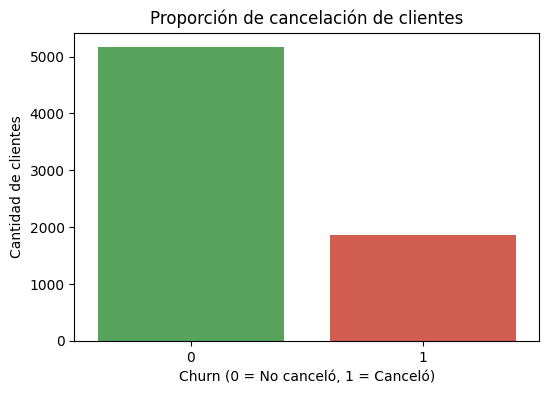

In [216]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', hue='Churn', data=df_codificado, palette=['#4CAF50', '#E74C3C'], legend=False)
plt.title('Proporción de cancelación de clientes')
plt.xlabel('Churn (0 = No canceló, 1 = Canceló)')
plt.ylabel('Cantidad de clientes')
plt.show()

## **🎯 Correlación y Selección de Variables**

### Análisis de Correlación

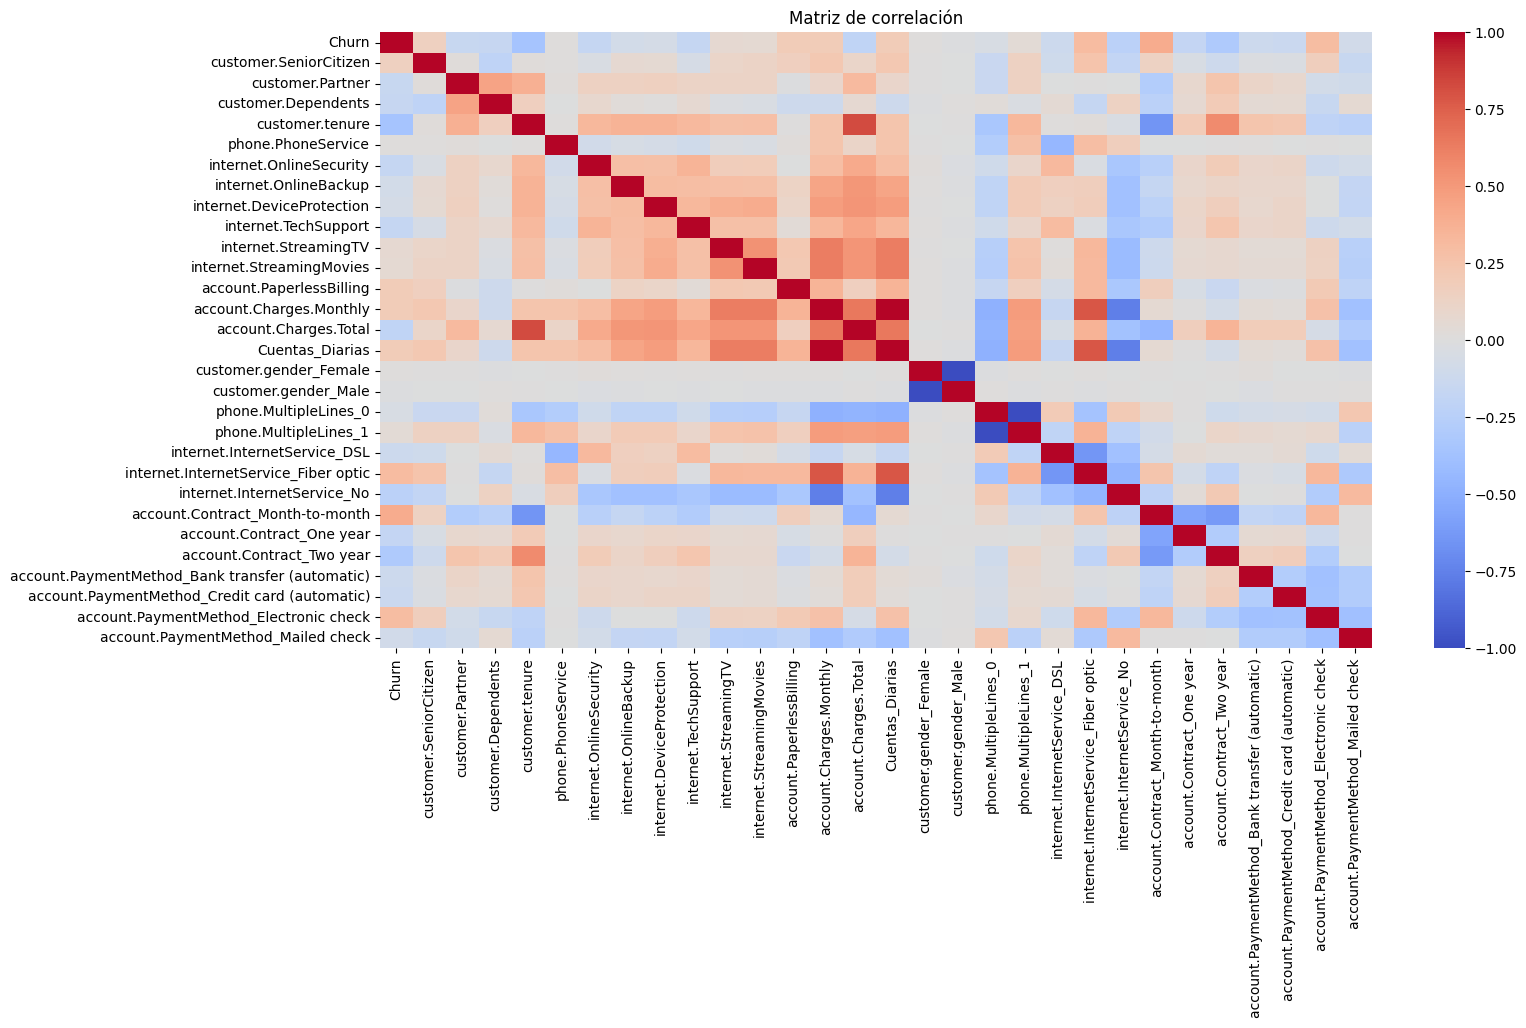

In [217]:
# Calculamos la matriz de correlación
corr = df_codificado.corr()

# Graficamos la matriz de correlación
plt.figure(figsize=(16,8))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

In [218]:
# Correlación de todas las variables con Churn
corr_churn = df_codificado.corr()['Churn'].sort_values(ascending=False)

print(corr_churn)

Churn                                              1.000000
account.Contract_Month-to-month                    0.404565
internet.InternetService_Fiber optic               0.307463
account.PaymentMethod_Electronic check             0.301455
Cuentas_Diarias                                    0.192858
account.Charges.Monthly                            0.192858
account.PaperlessBilling                           0.191454
customer.SeniorCitizen                             0.150541
internet.StreamingTV                               0.063254
internet.StreamingMovies                           0.060860
phone.MultipleLines_1                              0.040033
phone.PhoneService                                 0.011691
customer.gender_Female                             0.008545
customer.gender_Male                              -0.008545
phone.MultipleLines_0                             -0.040033
internet.DeviceProtection                         -0.066193
internet.OnlineBackup                   

### Análisis Dirigido

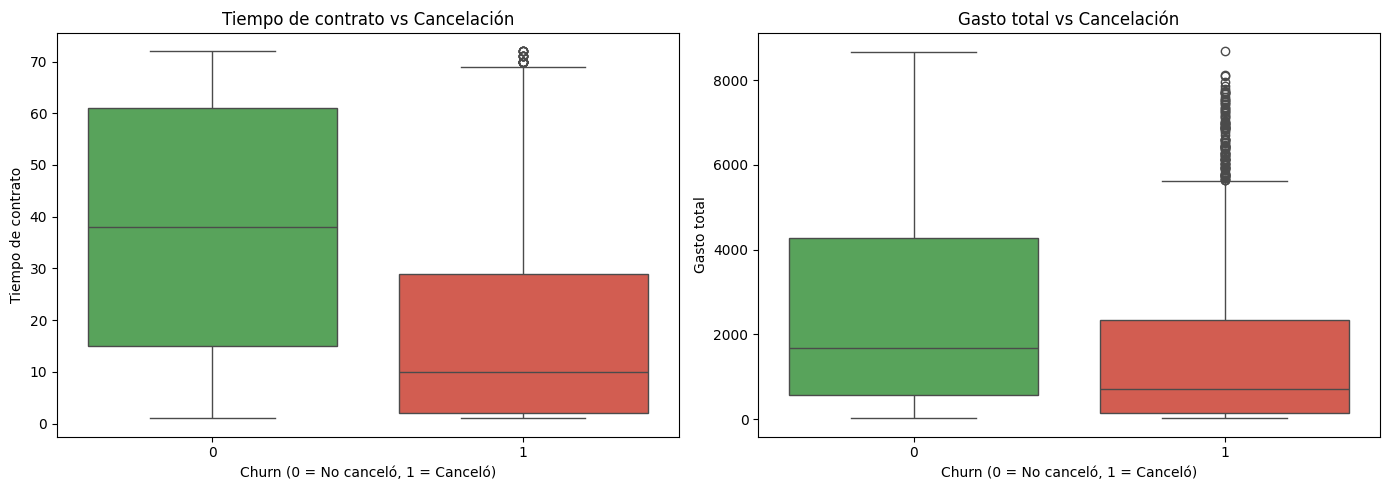

In [219]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

palette = ['#4CAF50', '#E74C3C']  # verde = no canceló, rojo = canceló

# Tiempo de contrato vs Cancelación
sns.boxplot(
    data=df_codificado,
    x='Churn',
    y='customer.tenure',
    hue='Churn',
    palette=palette,
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Tiempo de contrato vs Cancelación')
axes[0].set_xlabel('Churn (0 = No canceló, 1 = Canceló)')
axes[0].set_ylabel('Tiempo de contrato')

# Gasto total vs Cancelación
sns.boxplot(
    data=df_codificado,
    x='Churn',
    y='account.Charges.Total',
    hue='Churn',
    palette=palette,
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Gasto total vs Cancelación')
axes[1].set_xlabel('Churn (0 = No canceló, 1 = Canceló)')
axes[1].set_ylabel('Gasto total')

plt.tight_layout()
plt.show()

##**🤖 Modelado Predictivo**

### Separación de Datos

In [220]:
from sklearn.model_selection import train_test_split

# Variables predictoras
X = df_codificado.drop(columns=['Churn'])

y = df_codificado['Churn']

# Separación en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3,random_state=42,stratify=y)

### Creación de Modelos

In [221]:
#  Regresión Logística

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Normalización
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo
modelo_lr = LogisticRegression(random_state=42, max_iter=1000)

# Entrenamiento
modelo_lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [222]:
#RANDOM FOREST

from sklearn.ensemble import RandomForestClassifier

# Modelo
modelo_rf = RandomForestClassifier(random_state=42)

# Entrenamiento
modelo_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

###Evaluación de los Modelos

In [223]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Predicciones
ypred_lr = modelo_lr.predict(X_test_scaled)
ypred_rf = modelo_rf.predict(X_test)

In [224]:
#Regresión logistica
print(f"Accuracy: {accuracy_score(y_test, ypred_lr):.4f}")
print(f"Precision: {precision_score(y_test, ypred_lr):.4f}")
print(f"Recall: {recall_score(y_test, ypred_lr):.4f}")
print(f"F1-score: {f1_score(y_test, ypred_lr):.4f}")

print("Matriz de confusión:")
print(confusion_matrix(y_test, ypred_lr))

Accuracy: 0.8033
Precision: 0.6573
Recall: 0.5437
F1-score: 0.5951
Matriz de confusión:
[[1390  159]
 [ 256  305]]


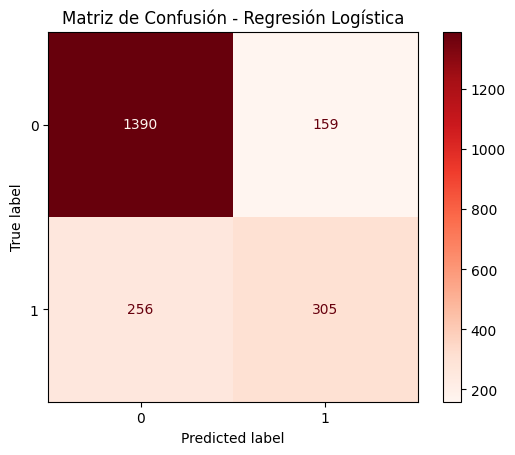

In [225]:
from sklearn.metrics import ConfusionMatrixDisplay

# Regresión Logística
cm_lr = confusion_matrix(y_test, ypred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp_lr.plot(cmap="Reds")
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

In [226]:
#Random Forest
print(f"Accuracy: {accuracy_score(y_test, ypred_rf):.4f}")
print(f"Precision: {precision_score(y_test, ypred_rf):.4f}")
print(f"Recall: {recall_score(y_test, ypred_rf):.4f}")
print(f"F1-score: {f1_score(y_test, ypred_rf):.4f}")

print("Matriz de confusión:")
print(confusion_matrix(y_test, ypred_rf))

Accuracy: 0.7877
Precision: 0.6323
Recall: 0.4813
F1-score: 0.5466
Matriz de confusión:
[[1392  157]
 [ 291  270]]


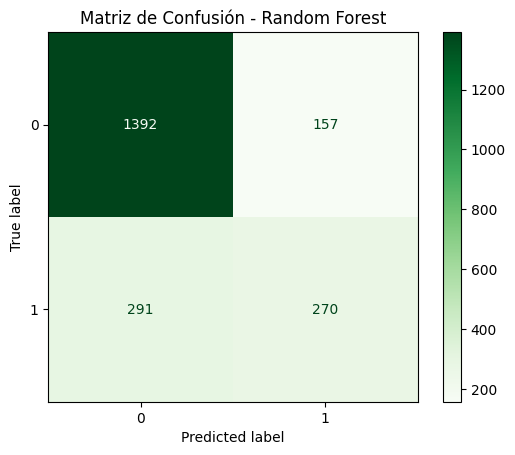

In [227]:
# Random Forest
cm_rf = confusion_matrix(y_test, ypred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap="Greens")
plt.title("Matriz de Confusión - Random Forest")
plt.show()

##**📋 Interpretación y Conclusiones**

###Análisis de la Importancia de las Variables

In [228]:
#Analizamos los coeficientes del modelo para observar
#qué variables tienen mayor impacto en la predicción Regresión Logística.
coefi_lr = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo_lr.coef_[0]
})

coefi_lr = coefi_lr.sort_values(by='Coeficiente', ascending=False)

print(coefi_lr.head(10))

                                  Variable  Coeficiente
13                   account.Charges.Total     0.641084
20    internet.InternetService_Fiber optic     0.556817
22         account.Contract_Month-to-month     0.291636
9                     internet.StreamingTV     0.215074
11                account.PaperlessBilling     0.180380
10                internet.StreamingMovies     0.169364
27  account.PaymentMethod_Electronic check     0.135781
0                   customer.SeniorCitizen     0.094965
18                   phone.MultipleLines_1     0.068149
7                internet.DeviceProtection     0.045042


/tmp/ipykernel_575/2309236693.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




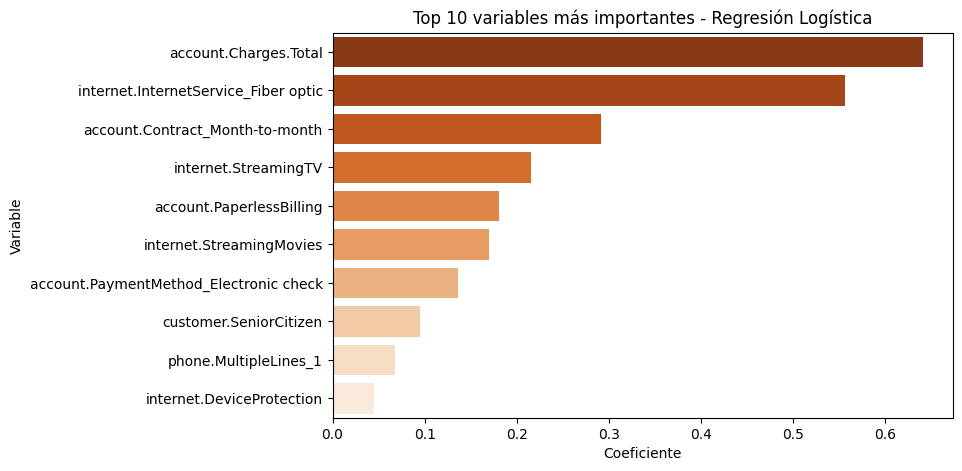

In [229]:
top_lr = coefi_lr.head(10)

plt.figure(figsize=(8,5))
sns.barplot(data=top_lr, x='Coeficiente', y='Variable', palette='Oranges_r')
plt.title('Top 10 variables más importantes - Regresión Logística')
plt.xlabel('Coeficiente')
plt.ylabel('Variable')
plt.show()

In [230]:
#Analizamos qué variables fueron más importantes
#para la toma de decisiones del modelo Random Forest
importancia_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_rf.feature_importances_
})

importancia_rf = importancia_rf.sort_values(by='Importancia', ascending=False)

print(importancia_rf.head(10))

                                  Variable  Importancia
13                   account.Charges.Total     0.155460
3                          customer.tenure     0.130886
12                 account.Charges.Monthly     0.129547
14                         Cuentas_Diarias     0.128214
22         account.Contract_Month-to-month     0.063852
20    internet.InternetService_Fiber optic     0.037553
27  account.PaymentMethod_Electronic check     0.033383
11                account.PaperlessBilling     0.024192
24               account.Contract_Two year     0.021322
1                         customer.Partner     0.021296


/tmp/ipykernel_575/876994645.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




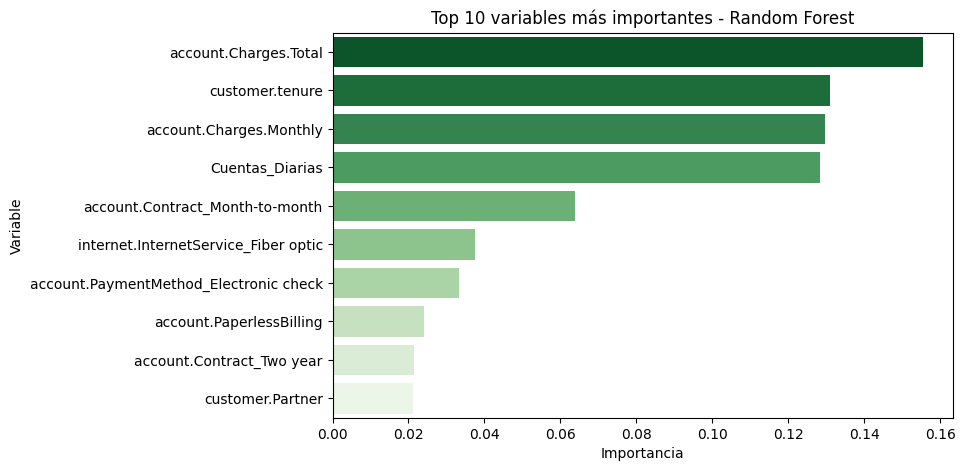

In [231]:
top_rf = importancia_rf.head(10)

plt.figure(figsize=(8,5))
sns.barplot(data=top_rf, x='Importancia', y='Variable', palette='Greens_r')
plt.title('Top 10 variables más importantes - Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.show()

## **Conclusiones del Informe de Predicción de Churn**

Este informe analizó la predicción de la tasa de abandono de clientes (**Churn**) en una empresa de telecomunicaciones utilizando técnicas de **preprocesamiento de datos** y modelos de **Machine Learning** como **Logistic Regression** y **Random Forest**.

---

### **Preparación y Análisis de Datos**

* Se cargó el dataset y se eliminó la columna **customerID**, ya que no aporta valor para predecir **Churn**.
* Las variables categóricas se transformaron usando **One-Hot Encoding**, lo que generó un dataset con **30 variables numéricas**.
* Se identificó un **desbalance en la variable objetivo `Churn`**:
  * **73.4%** de los clientes no cancelan el servicio.
  * **26.6%** sí cancelan.
* El análisis de correlación mostró que **Churn** se relaciona principalmente con:
  * `account.Contract_Month-to-month`
  * `internet.InternetService_Fiber optic`
  * `account.PaymentMethod_Electronic check`
  * `account.Charges.Total`
  * `customer.tenure`

En general, los clientes con **contratos mensuales, fibra óptica, pagos electrónicos y menor antigüedad** presentan mayor probabilidad de cancelar el servicio.

---

### **Modelado Predictivo**

Se entrenaron dos modelos de clasificación para predecir **Churn**:

#### **Logistic Regression**
* **Accuracy:** 0.8033  
* **Precision:** 0.6573  
* **Recall:** 0.5437  
* **F1-score:** 0.5951  

Este modelo mostró **el mejor rendimiento general**, logrando un buen equilibrio entre detectar clientes que cancelan y mantener predicciones correctas.

#### **Random Forest**
* **Accuracy:** 0.7877  
* **Precision:** 0.6323  
* **Recall:** 0.4813  
* **F1-score:** 0.5466  

Aunque tuvo un desempeño ligeramente menor que **Logistic Regression**, también presentó resultados sólidos para la predicción.

---

### **Importancia de las Variables**

* **Logistic Regression:**  
  Las variables con mayor impacto en **Churn** fueron  
  `account.Charges.Total`, `internet.InternetService_Fiber optic` y `account.Contract_Month-to-month`.

* **Random Forest:**  
  Las variables más importantes fueron  
  `account.Charges.Total`, `customer.tenure`, `account.Charges.Monthly` y `Cuentas_Diarias`.

Esto indica que **los costos del servicio y la antigüedad del cliente** son factores clave en la cancelación.

---

### **Recomendaciones**

Para reducir la tasa de **Churn**, la empresa podría:

1. **Fomentar contratos de mayor duración** para clientes con `account.Contract_Month-to-month`.
2. **Analizar la experiencia de usuarios de `internet.InternetService_Fiber optic`** para identificar posibles problemas en el servicio.
3. **Revisar la estructura de precios**, especialmente en `account.Charges.Monthly` y `account.Charges.Total`.
4. **Implementar estrategias de retención para clientes nuevos**, ya que los clientes con menor `customer.tenure` tienden a cancelar más.

---

### **Conclusión**

Ambos modelos aportan información valiosa para comprender el **Churn**.  
**Logistic Regression** destacó por su mejor desempeño y facilidad de interpretación, mientras que **Random Forest** permitió identificar las variables más influyentes en la predicción.

Estos resultados permiten tomar **decisiones estratégicas basadas en datos** para mejorar la **retención de clientes y reducir la cancelación del servicio**.